### Algorisme d'agrupament espectral aplicat al sistema de Duffing no autònom

In [1]:
import sys
sys.path.append("..")
from src import *
import numpy as np
np.set_printoptions(precision=3, suppress=True)
%load_ext autoreload
%autoreload 2

In [2]:
params = ParametresGenerals(
    dimensio = 2,
    t_span = (0, 4 * np.pi),
    t_steps = 300,
    x_min = -2,
    x_max = 2,
    y_min = -1,
    y_max = 1,
    espai_entre_punts = 0.04,
    max_clusters = 50,
    num_radis = 50
    )

In [3]:
condicions_inicials = generar_condicions_inicials(params)
trajectories = generar_trajectories(edo_duffing_no_autonom, condicions_inicials, params)
print("(Num trajectories, t_steps, dimensio) =", trajectories.shape)

(Num trajectories, t_steps, dimensio) = (5151, 300, 2)


In [4]:
matriu_pesos = calcula_matriu_pesos(trajectories)

In [5]:
pes_max = np.max(matriu_pesos)
print(f"Pes màxim a la matriu de pesos: {pes_max:.3f}")
constant_diagonal = pes_max * 1e7

Pes màxim a la matriu de pesos: 159.460


S'ha obtingut una esparsificació del 90% usant 1.191 com a radi d'esparsificació.
matriu_similaritat_W =
 [[1.595e+09 2.355e+00 0.000e+00 ... 0.000e+00 0.000e+00 0.000e+00]
 [2.355e+00 1.595e+09 1.692e+00 ... 0.000e+00 0.000e+00 0.000e+00]
 [0.000e+00 1.692e+00 1.595e+09 ... 0.000e+00 0.000e+00 0.000e+00]
 ...
 [0.000e+00 0.000e+00 0.000e+00 ... 1.595e+09 4.838e+00 2.580e+00]
 [0.000e+00 0.000e+00 0.000e+00 ... 4.838e+00 1.595e+09 5.437e+00]
 [0.000e+00 0.000e+00 0.000e+00 ... 2.580e+00 5.437e+00 1.595e+09]]
veps.shape = (5151, 50)
50 vaps = [-3.6e-19 9.0e-10 2.7e-09 3.0e-09 4.0e-09 4.6e-09 6.8e-09 7.8e-09 1.1e-08
 1.2e-08 1.7e-08 2.0e-08 2.0e-08 2.2e-08 2.5e-08 2.7e-08 2.9e-08 3.0e-08
 3.1e-08 3.2e-08 3.2e-08 3.3e-08 3.4e-08 3.5e-08 3.5e-08 3.6e-08 3.7e-08
 3.7e-08 3.8e-08 3.8e-08 3.8e-08 4.0e-08 4.1e-08 4.1e-08 4.1e-08 4.2e-08
 4.3e-08 4.4e-08 4.5e-08 4.5e-08 4.5e-08 4.6e-08 4.7e-08 4.7e-08 4.7e-08
 4.8e-08 4.9e-08 4.9e-08 4.9e-08 5.0e-08]


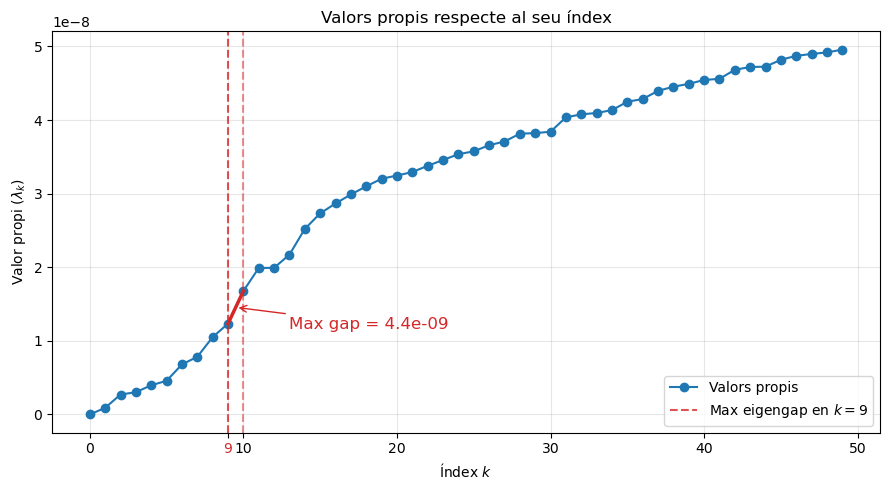

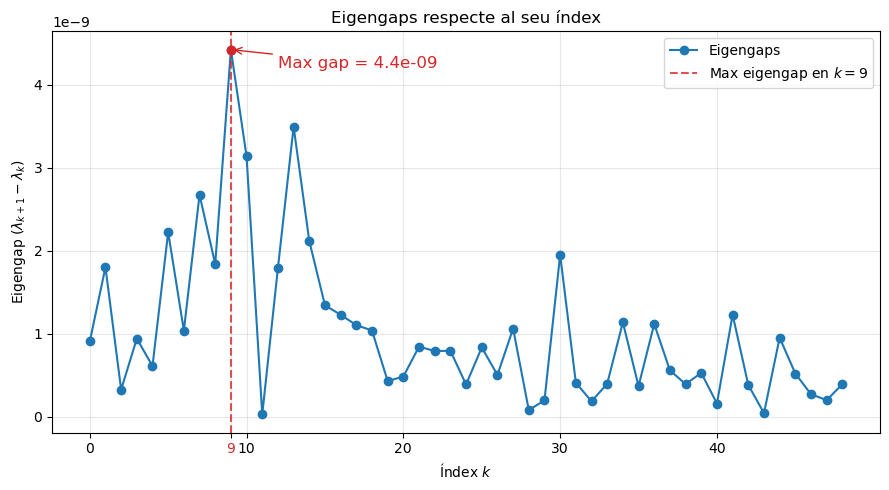

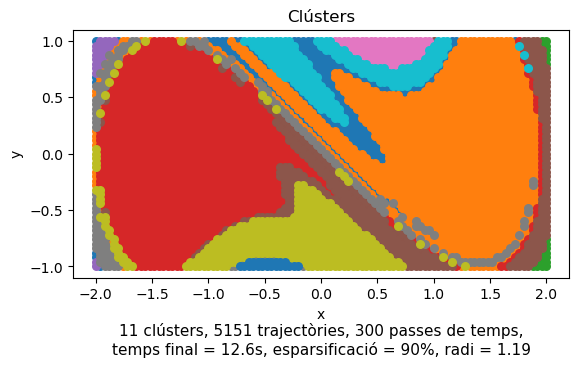

In [6]:
# Opció A: esparsificar al 90%
matriu_similaritat_W, radi_esparsificacio, percentatge_esparsificacio = \
      sparcify(matriu_pesos, percent=90)
print(f"S'ha obtingut una esparsificació del {percentatge_esparsificacio*100:.0f}% "
      f"usant {radi_esparsificacio:.3f} com a radi d'esparsificació.")
np.fill_diagonal(matriu_similaritat_W, constant_diagonal)
print("matriu_similaritat_W =\n", matriu_similaritat_W)
vaps, veps = calcula_vaps(matriu_similaritat_W, params.max_clusters)
print("veps.shape =", veps.shape)
print(len(vaps),"vaps =",
      np.array2string(vaps,formatter={'float_kind':lambda x:f'{x:.1e}'}))
grafica_eigenvalues_vs_index(vaps, subfolder="no_autonom")
grafica_eigengaps_vs_index(vaps, subfolder="no_autonom")
num_clusters, diff_max = calcula_num_clusters_i_max_eigengap(vaps)
labels = troba_clusters(num_clusters, veps)
grafica_clusters(condicions_inicials, labels, num_clusters, radi_esparsificacio, 
                 percentatge_esparsificacio, params, subfolder="no_autonom")

In [7]:
# Opció B: mètode adaptatiu. 
# Triar els radis d'esparsificació que maximitzen l'eigengap màxim
result = calcula_indicadors_vs_radis(matriu_pesos, constant_diagonal, params)

indexs_max_rel = [2, 9, 26, 31, 34, 36, 47]
radis[indexs_max_rel] = [0.32  0.519 1.002 1.144 1.23  1.287 1.6  ]
Màxim_relatiu_num 1
Radi: 0.320, Esparsificació: 0.27%, Clústers: 2, Max eigengap: 1.45384e-06


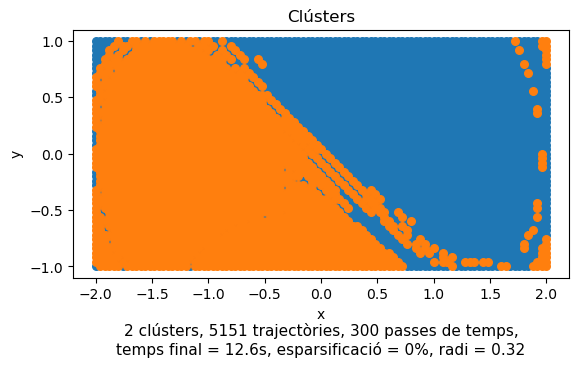

Màxim_relatiu_num 2
Radi: 0.519, Esparsificació: 40.81%, Clústers: 2, Max eigengap: 3.34875e-07


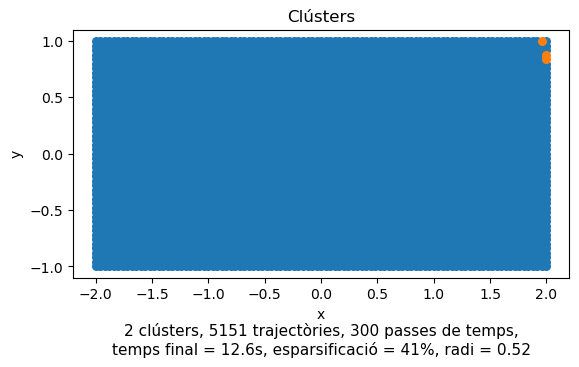

Màxim_relatiu_num 3
Radi: 1.002, Esparsificació: 85.34%, Clústers: 10, Max eigengap: 5.86202e-09


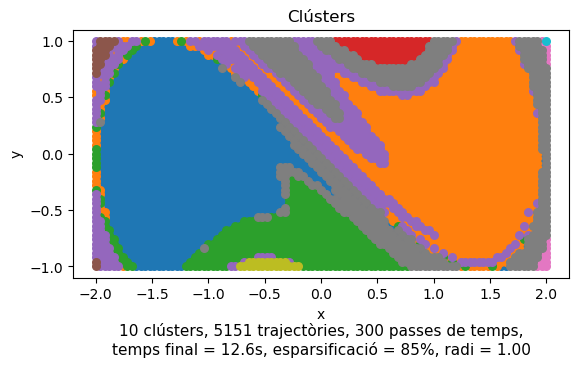

Màxim_relatiu_num 4
Radi: 1.144, Esparsificació: 89.09%, Clústers: 11, Max eigengap: 5.24389e-09


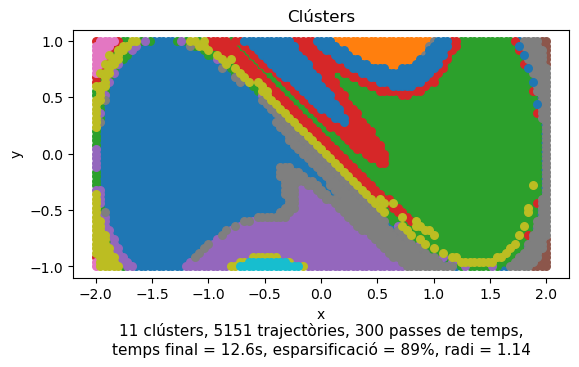

Màxim_relatiu_num 5
Radi: 1.230, Esparsificació: 90.68%, Clústers: 15, Max eigengap: 5.86901e-09


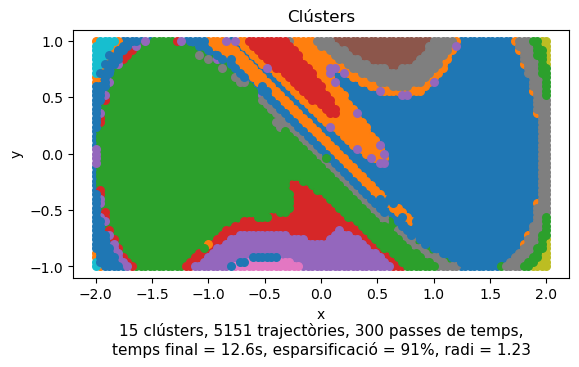

Màxim_relatiu_num 6
Radi: 1.287, Esparsificació: 91.54%, Clústers: 15, Max eigengap: 5.35113e-09


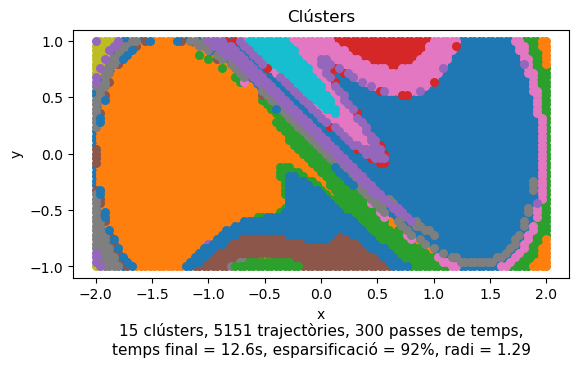

Màxim_relatiu_num 7
Radi: 1.600, Esparsificació: 94.63%, Clústers: 36, Max eigengap: 1.30554e-09


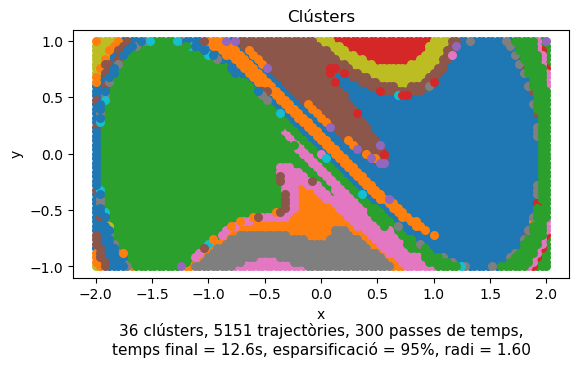

In [8]:
indexs_max_rel = troba_indexs_max_rel(result.normalized_eigengaps)
print("indexs_max_rel =", indexs_max_rel)
print("radis[indexs_max_rel] =", result.radis[indexs_max_rel])
grafica_clusters_maxs_rel(indexs_max_rel, result, condicions_inicials, 
                          params, subfolder="no_autonom_maxs_rels")

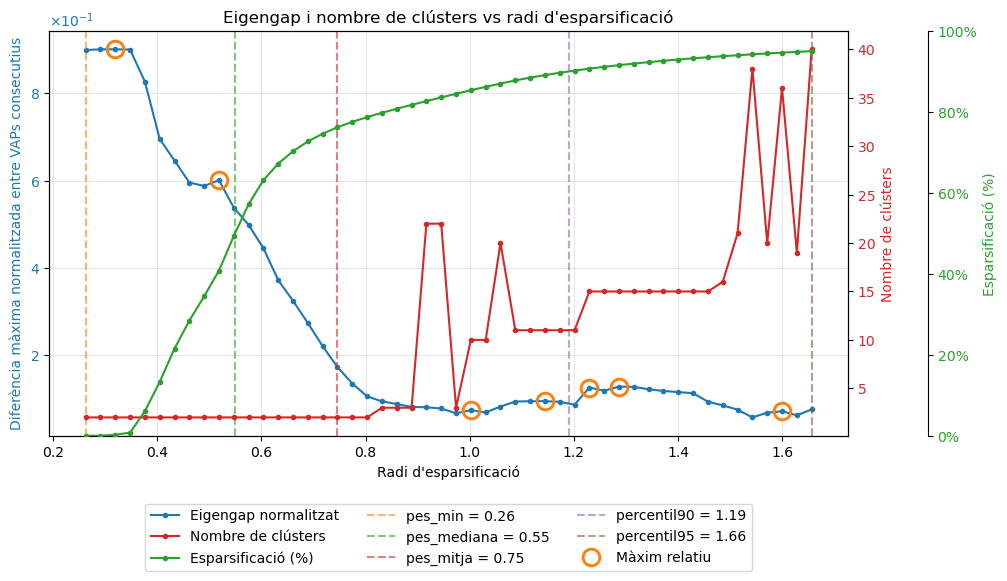

In [9]:
grafica_eigengaps_vs_radi(result, params, indexs_max_rel=indexs_max_rel, 
                          subfolder="no_autonom_maxs_rels")